In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 
from scipy.optimize import curve_fit
import scipy.constants as const
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from scipy import constants 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm  # Importing tqdm for progress bar
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from scipy.optimize import curve_fit
from ipywidgets import interact, IntSlider
import pickle
# Generalized variables
textwidth_cm = 15  # Text width in cm
aspect_ratio = 0.618     # Aspect ratio (height/width) using the golden ratio

# Font sizes
label_fontsize = 12
legend_fontsize = 12
colorbar_label_fontsize = 12
colorbar_tick_fontsize = 10
offset_text_fontsize = 12
tick_fontsize = 10
errorbar_capsize = 5

# Convert text width from cm to inches
textwidth_in = textwidth_cm / 2.54

# Calculate figure size based on text width and aspect ratio
fig_width = textwidth_in
fig_height = textwidth_in * aspect_ratio

plt.rcParams["figure.figsize"] = [fig_width, fig_height]


plt.rc('font', size=label_fontsize)          # controls default text sizes
plt.rc('axes', titlesize=legend_fontsize)    # fontsize of the axes title
plt.rc('axes', labelsize=tick_fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('ytick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('legend', fontsize=legend_fontsize)   # legend fontsize

save_dir = '/home/pkruyt/cernbox/figures_thesis_pdf/cooling_rates_ions/'


In [27]:
from ion_properties import lead,calcium,xenon,xenon2nd


Also plot dp/p

In [28]:
ion_loop=xenon

data_cooling = np.load(f'results/transverse/{ion_loop.name}_cooling.npz')

delta_cooling = data_cooling['delta']
zeta_cooling = data_cooling['zeta']
state_cooling = data_cooling['state']
x_cooling = data_cooling['x'] 
time = data_cooling['time']
s_per_turn = data_cooling['s_per_turn']
px_cooling = data_cooling['px']
action_x_cooling = data_cooling['action_x']
action_y_cooling = data_cooling['action_y']
emittance_x_cooling = data_cooling['emittance_x']
rms_dp_p_cooling = np.std(delta_cooling, axis=1)

data_heating = np.load(f'results/transverse/{ion_loop.name}_heating.npz')

delta_heating = data_heating['delta']
zeta_heating = data_heating['zeta']
state_heating = data_heating['state']
x_heating = data_heating['x'] 
time = data_heating['time']
s_per_turn = data_heating['s_per_turn']
px_heating = data_heating['px']
action_x_heating = data_heating['action_x']
action_y_heating = data_heating['action_y']
emittance_x_heating = data_heating['emittance_x']
rms_dp_p_heating = np.std(delta_heating, axis=1)

data_heating2= np.load(f'results/transverse/{ion_loop.name}_heating2.npz')

delta_heating2 = data_heating2['delta']
action_x_heating2 = data_heating2['action_x']
emittance_x_heating2 = data_heating2['emittance_x']
rms_dp_p_heating2 = np.std(delta_heating2, axis=1)

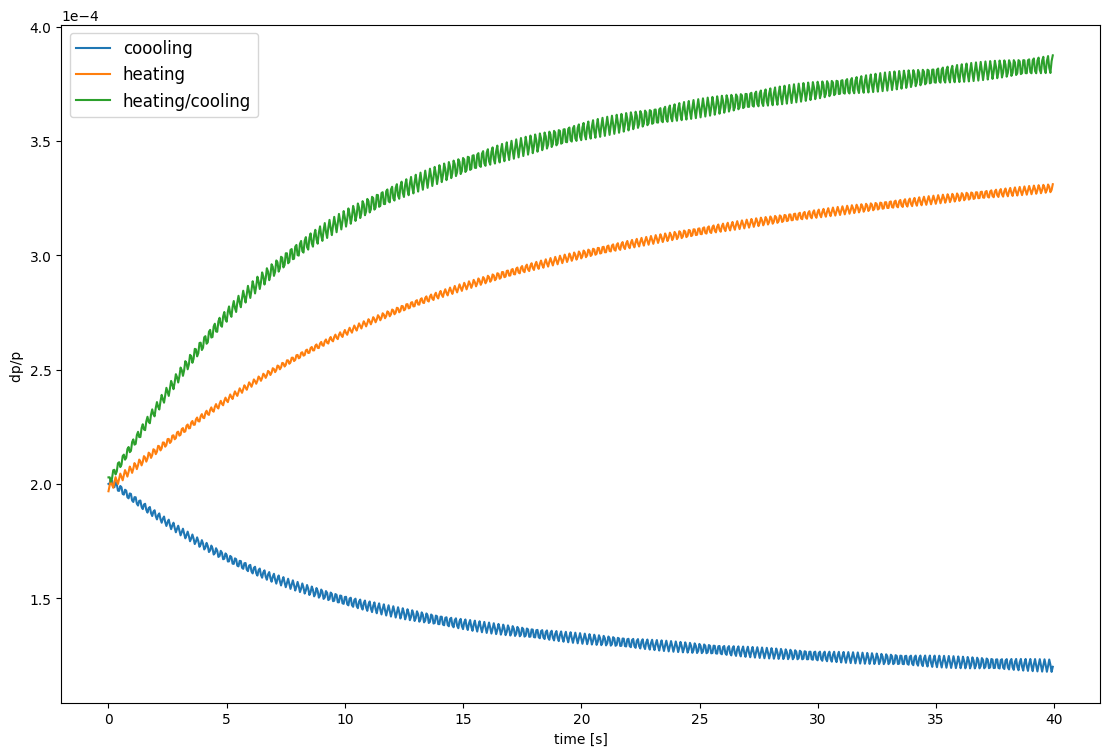

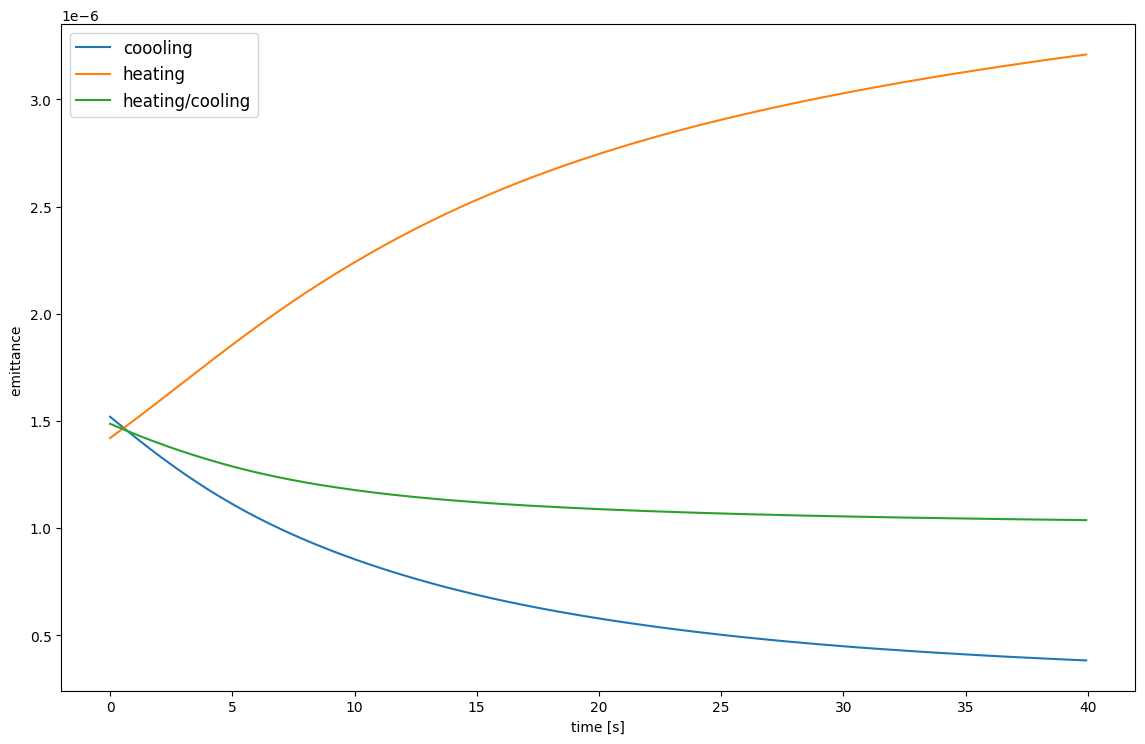

In [29]:
plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 25})
plt.plot(time,rms_dp_p_cooling,label='coooling') #turns,particles
plt.plot(time,rms_dp_p_heating,label='heating') #turns,particles
plt.plot(time,rms_dp_p_heating2,label='heating/cooling') #turns,particles
plt.xlabel('time [s]')
plt.ylabel('dp/p ')
plt.tight_layout()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend()
plt.show()


plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 25})
plt.plot(time,emittance_x_cooling,label='coooling') #turns,particles
plt.plot(time,emittance_x_heating,label='heating') #turns,particles
plt.plot(time,emittance_x_heating2,label='heating/cooling') #turns,particles
plt.xlabel('time [s]')
plt.ylabel('emittance ')
plt.tight_layout()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend()
plt.show()

min_laser_offset: -2.142857142857143


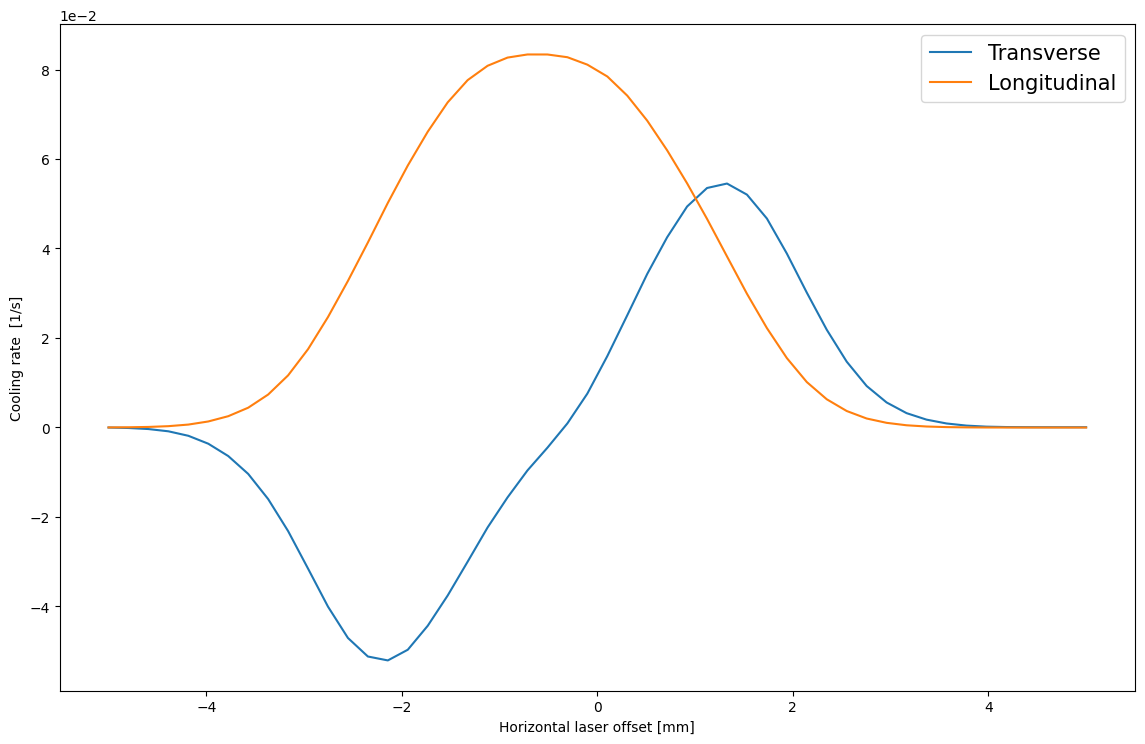

In [30]:
plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 25})

for ion_loop in [xenon]:# Ion properties:       
    data = np.load(f'results/optimal_laser_x/{ion_loop.name}_heating.npz')  # Replace 'ion_name' with the appropriate value

    # Access the variables stored in the file
    transverse_growth_rate_list = data['transverse_growth_rate_list']
    longitudinal_growth_rate_list = data['longitudinal_growth_rate_list']
    final_emittance_list = data['final_emittance_list']
    laser_x_list = data['laser_x_list']
    nemitt = data['nemitt']
    time = data['time']

    ######################################################################
    # Find laser position with minimal final emittance

    min_index = np.argmin(transverse_growth_rate_list)
    min_laser_offset = laser_x_list[min_index]

    print('min_laser_offset:',min_laser_offset*1e3)
    
    
    plt.plot(laser_x_list*1e3,transverse_growth_rate_list,label=f'Transverse')    
    plt.plot(laser_x_list*1e3,longitudinal_growth_rate_list,label=f'Longitudinal')   
plt.xlabel('Horizontal laser offset [mm]')
plt.ylabel('Cooling rate  [1/s]')
ax = plt.gca()
# Removing the offset from the y-axis tick labels
ax.yaxis.get_major_formatter().set_useOffset(False)
# plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
# plt.axvline(-1.7346938775510203,color='red')
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

min_laser_offset: -1.3265306122448979


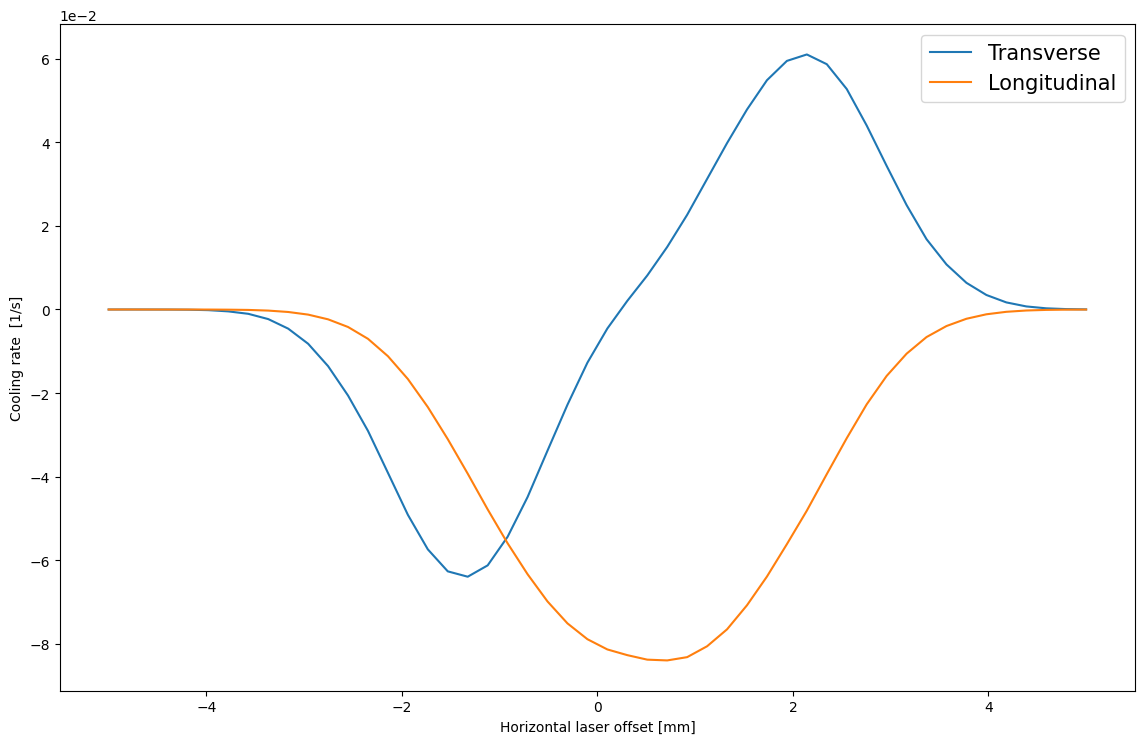

In [31]:
plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 25})

for ion_loop in [xenon]:# Ion properties:       
    data = np.load(f'results/optimal_laser_x/{ion_loop.name}_cooling.npz')  # Replace 'ion_name' with the appropriate value

    # Access the variables stored in the file
    transverse_growth_rate_list = data['transverse_growth_rate_list']
    longitudinal_growth_rate_list = data['longitudinal_growth_rate_list']
    final_emittance_list = data['final_emittance_list']
    laser_x_list = data['laser_x_list']
    nemitt = data['nemitt']
    time = data['time']

    ######################################################################
    # Find laser position with minimal final emittance

    min_index = np.argmin(transverse_growth_rate_list)
    min_laser_offset = laser_x_list[min_index]

    print('min_laser_offset:',min_laser_offset*1e3)
    
    
    plt.plot(laser_x_list*1e3,transverse_growth_rate_list,label=f'Transverse')    
    plt.plot(laser_x_list*1e3,longitudinal_growth_rate_list,label=f'Longitudinal')   
plt.xlabel('Horizontal laser offset [mm]')
plt.ylabel('Cooling rate  [1/s]')
ax = plt.gca()
# Removing the offset from the y-axis tick labels
ax.yaxis.get_major_formatter().set_useOffset(False)
# plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
# plt.axvline(-1.7346938775510203,color='red')
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

In [39]:
data.keys()

KeysView(NpzFile 'results/2d_cooling_rates.npz' with keys: transverse_growth_rates, longitudinal_growth_rates, gamma_list, laser_x_list)

In [38]:
time[-1]

np.float64(0.5889807375924011)

min_laser_offset: -1.5306122448979593


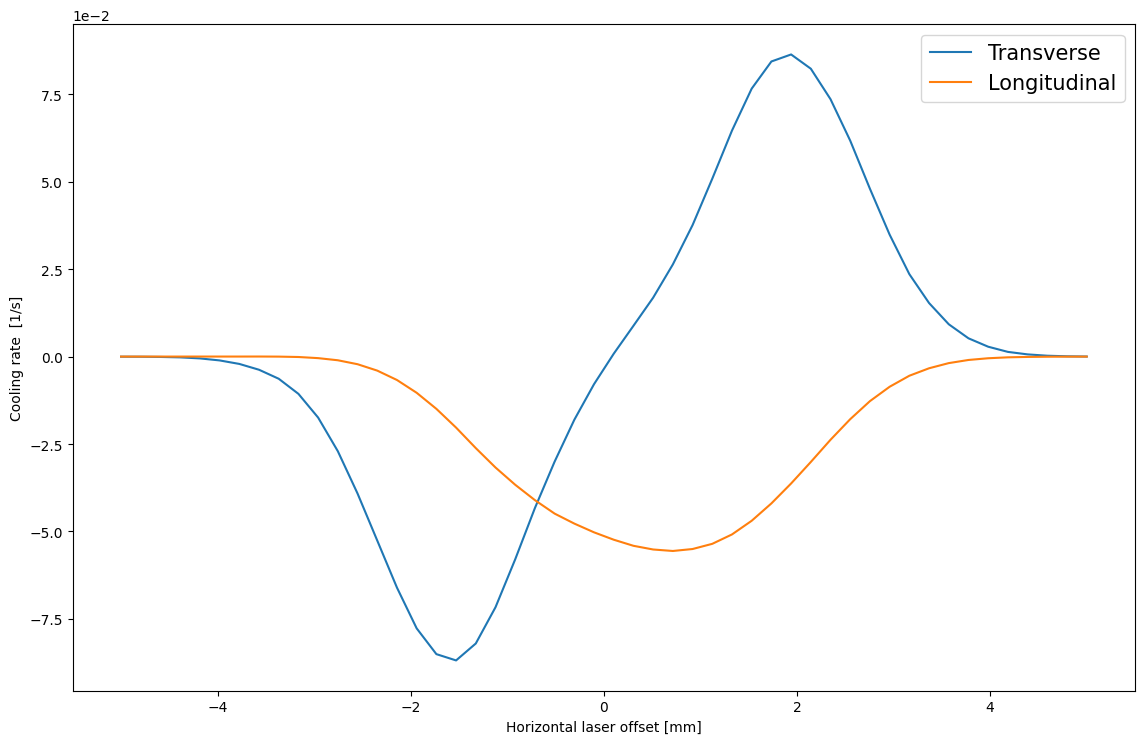

In [32]:
plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 25})

for ion_loop in [xenon]:# Ion properties:       
    data = np.load(f'results/optimal_laser_x/{ion_loop.name}.npz')  # Replace 'ion_name' with the appropriate value

    # Access the variables stored in the file
    transverse_growth_rate_list = data['transverse_growth_rate_list']
    longitudinal_growth_rate_list = data['longitudinal_growth_rate_list']
    final_emittance_list = data['final_emittance_list']
    laser_x_list = data['laser_x_list']
    nemitt = data['nemitt']
    time = data['time']

    ######################################################################
    # Find laser position with minimal final emittance

    min_index = np.argmin(transverse_growth_rate_list)
    min_laser_offset = laser_x_list[min_index]

    print('min_laser_offset:',min_laser_offset*1e3)
    
    
    plt.plot(laser_x_list*1e3,transverse_growth_rate_list,label=f'Transverse')    
    plt.plot(laser_x_list*1e3,longitudinal_growth_rate_list,label=f'Longitudinal')   
plt.xlabel('Horizontal laser offset [mm]')
plt.ylabel('Cooling rate  [1/s]')
ax = plt.gca()
# Removing the offset from the y-axis tick labels
ax.yaxis.get_major_formatter().set_useOffset(False)
# plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
# plt.axvline(-1.7346938775510203,color='red')
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

find the point with only transverse cooling and no longitudinal cooling

In [33]:
import numpy as np

# Load the saved data
data = np.load('results/2d_cooling_rates.npz')

# Extract the arrays
transverse_growth_rates = data['transverse_growth_rates']
longitudinal_growth_rates = data['longitudinal_growth_rates']
gamma_list = data['gamma_list']
laser_x_list = data['laser_x_list']

# Find indices where longitudinal growth rates are less than 0.02
longitudinal_zero_indices = np.where((longitudinal_growth_rates >= -10) & (longitudinal_growth_rates <= 10))

# Extract corresponding transverse growth rates
a = transverse_growth_rates[longitudinal_zero_indices]

# Find the index of the most negative value in a
index_of_min_neg = np.argmax(-a)

# Get the corresponding indices in gamma_list and laser_x_list
corresponding_indices_neg = np.unravel_index(longitudinal_zero_indices[0][index_of_min_neg], transverse_growth_rates.shape)

# Get the corresponding values of gamma and laser offset
corresponding_gamma_neg = gamma_list[corresponding_indices_neg[0]]
corresponding_laser_offset_neg = laser_x_list[corresponding_indices_neg[1]]

print("Most negative transverse growth rate value:", a[index_of_min_neg])
print("Corresponding gamma value:", corresponding_gamma_neg)
print("Corresponding laser offset value:", corresponding_laser_offset_neg*1e3)


Most negative transverse growth rate value: -0.08859877789684294
Corresponding gamma value: 152.500998975125
Corresponding laser offset value: -1.7346938775510203


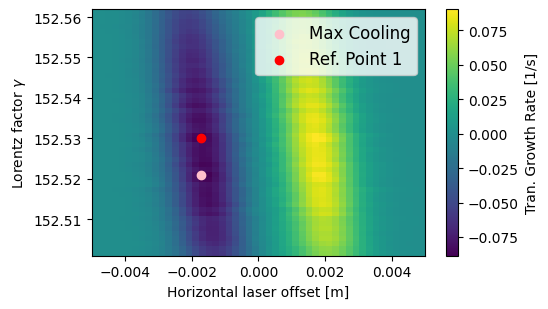

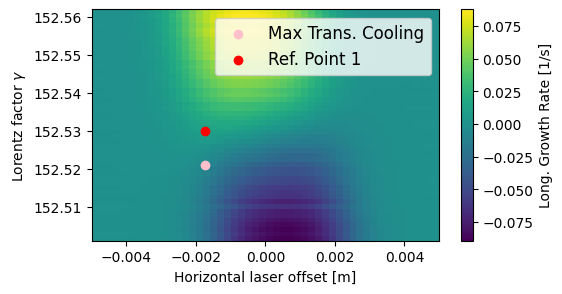

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Load the saved data
data = np.load('results/2d_cooling_rates.npz')

# Extract the arrays
transverse_growth_rates = data['transverse_growth_rates']
longitudinal_growth_rates = data['longitudinal_growth_rates']
gamma_list = data['gamma_list']
laser_x_list = data['laser_x_list']  # Already in mm

# Find the minimum transverse growth rate (maximum cooling)
min_idx = np.unravel_index(np.argmin(transverse_growth_rates), transverse_growth_rates.shape)
optimal_gamma = gamma_list[min_idx[0]]
optimal_laser_x = laser_x_list[min_idx[1]]

# === Transverse Growth Rate Plot ===
fig=plt.figure()
plt.imshow(transverse_growth_rates, extent=[laser_x_list[0], laser_x_list[-1], gamma_list[0], gamma_list[-1]],
           aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label='Tran. Growth Rate [1/s]')
plt.xlabel('Horizontal laser offset [m]')
plt.ylabel('Lorentz factor $\\gamma$')
plt.scatter(optimal_laser_x, optimal_gamma, color='pink', marker='o', label='Max Cooling')
plt.scatter(-1.7346938775510203e-3, 152.53, color='red', marker='o', label='Ref. Point 1')
plt.gca().get_yaxis().get_major_formatter().set_useOffset(False)
plt.legend()
plt.tight_layout()
image_name = 'xenon_2d_transverse.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')
# Define your pickle filename
pickle_filename = 'xenon_2d_transverse.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
# Save the figure object 'fig' using pickle
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)
#plt.savefig('figures/Equilibrium_emittance.png', dpi=300)
plt.show()

# === Longitudinal Growth Rate Plot ===
fig=plt.figure()
plt.imshow(longitudinal_growth_rates, extent=[laser_x_list[0], laser_x_list[-1], gamma_list[0], gamma_list[-1]],
           aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label='Long. Growth Rate [1/s]')
plt.xlabel('Horizontal laser offset [m]')
plt.ylabel('Lorentz factor $\\gamma$')
plt.scatter(optimal_laser_x, optimal_gamma, color='pink', marker='o', label='Max Trans. Cooling')
plt.scatter(-1.7346938775510203e-3, 152.53, color='red', marker='o', label='Ref. Point 1')
plt.legend()
plt.tight_layout()
plt.gca().get_yaxis().get_major_formatter().set_useOffset(False)
image_name = 'xenon_2d_longitudinal.pdf'
save_location = os.path.join(save_dir, image_name)
plt.savefig(save_location, dpi=300, bbox_inches='tight')
# Define your pickle filename
pickle_filename = 'xenon_2d_longitudinal.pkl'
pickle_file_path = os.path.join(save_dir, pickle_filename)
# Save the figure object 'fig' using pickle
with open(pickle_file_path, 'wb') as f:
    pickle.dump(fig, f)
#plt.savefig('figures/Equilibrium_emittance.png', dpi=300)
plt.show()


In [40]:
# Convert coordinates to indices for the grid
def find_closest_index(array, value):
    return (np.abs(array - value)).argmin()

# Reference point
ref_x = -1.7346938775510203e-3
ref_gamma = 152.53
ref_x_idx = find_closest_index(laser_x_list, ref_x)
ref_gamma_idx = find_closest_index(gamma_list, ref_gamma)

# Optimal point (already computed)
opt_x_idx = min_idx[1]
opt_gamma_idx = min_idx[0]

# Extract values
ref_trans = transverse_growth_rates[ref_gamma_idx, ref_x_idx]
ref_long = longitudinal_growth_rates[ref_gamma_idx, ref_x_idx]
opt_trans = transverse_growth_rates[opt_gamma_idx, opt_x_idx]
opt_long = longitudinal_growth_rates[opt_gamma_idx, opt_x_idx]

# Print them
print(f"Reference Point:")
print(f"  Transverse growth rate = {ref_trans:.3e}  [1/s]")
print(f"  Longitudinal growth rate = {ref_long:.3e}  [1/s]\n")

print(f"Optimal Cooling Point:")
print(f"  Transverse growth rate = {opt_trans:.3e}  [1/s]")
print(f"  Longitudinal growth rate = {opt_long:.3e}  [1/s]")


Reference Point:
  Transverse growth rate = -8.808e-02  [1/s]
  Longitudinal growth rate = 1.024e-02  [1/s]

Optimal Cooling Point:
  Transverse growth rate = -8.860e-02  [1/s]
  Longitudinal growth rate = -7.354e-03  [1/s]


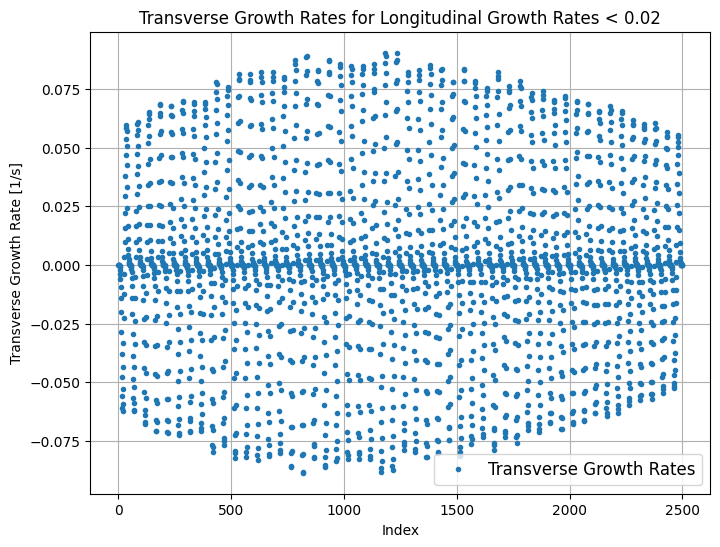

In [35]:
plt.figure(figsize=(8, 6))
plt.plot(a, 'o', markersize=3, label='Transverse Growth Rates')
plt.xlabel('Index')
plt.ylabel('Transverse Growth Rate [1/s]')
plt.title('Transverse Growth Rates for Longitudinal Growth Rates < 0.02')
plt.legend()
plt.grid(True)
plt.show()


slice on plane

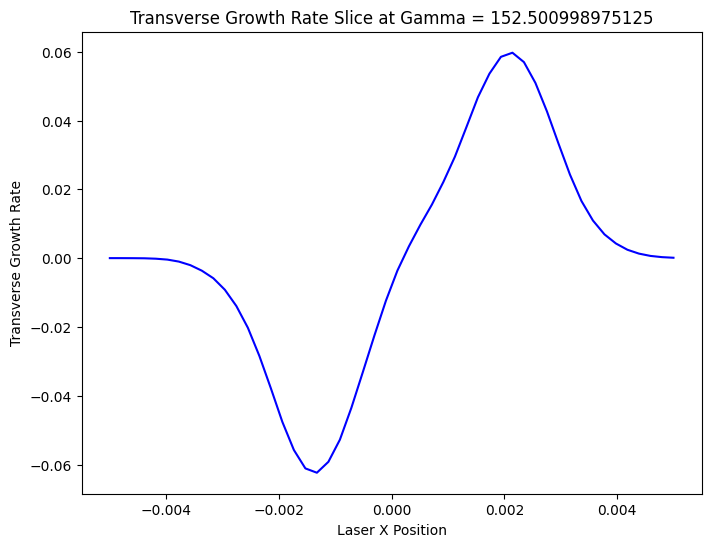

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Load the saved data
data = np.load('results/2d_cooling_rates.npz')

# Extract the arrays
transverse_growth_rates = data['transverse_growth_rates']
longitudinal_growth_rates = data['longitudinal_growth_rates']
gamma_list = data['gamma_list']
laser_x_list = data['laser_x_list']

# Choose the gamma value for the slice
gamma_value = gamma_list[0]  # Change this to the desired gamma value

# Find the index of the gamma value in the gamma list
gamma_index = np.abs(gamma_list - gamma_value).argmin()

# Plot the slice for transverse growth rates
plt.figure(figsize=(8, 6))
plt.plot(laser_x_list, transverse_growth_rates[gamma_index, :], color='blue')
plt.xlabel('Laser X Position')
plt.ylabel('Transverse Growth Rate')
plt.title(f'Transverse Growth Rate Slice at Gamma = {gamma_value}')
plt.show()
